# Encontro 3 - Insper AI - Atividade Prévia: Revisão de Conceitos Essenciais

---
*Autor: Vitor Assis Salomão*  
*Colaboradores: Thomas Kassabian*  
*Atualizado em: 09/2025*  

---

## Revisão de Conceitos Essenciais: Machine Learning Supervisionado

Este notebook retoma alguns dos conceitos fundamentais de aprendizado supervisionado vistos até aqui em uma atividade focada em visualizações, abordando classificação vs. regressão, função de custo e otimização por Gradient Descent.

### Objetivo:
Revisar e consolidar os **conceitos fundamentais de Machine Learning supervisionado** através de visualizações interativas e implementação prática.

### Etapas:
1. **Configuração: Instalação e Importação de Bibliotecas**
2. **Supervised Learning**
3. **Regressão Linear**
4. **Regressão Logística**
5. **Fronteira de Decisão**
6. **Função de Custo**
7. **Treinamento: Gradiente Descendente**
8. **Implementação passo a passo — Modelo de Regressão Linear**
9. **Conclusão**
10. **Breve Introdução a Deep Learning e Redes Neurais**

### Instruções:
- Este notebook é um material de revisão para consolidar conceitos já vistos
- Execute as células de código e experimente com os controles interativos
- Foque na compreensão visual dos conceitos através das simulações
- Nas ultimas seções, existem algumas células para você implementar

---

## 1. Configuração: Instalação e Importação de Bibliotecas

Se você tiver instalado o UV, de acordo com o tutorial do último encontro, apenas rode o comando abaixo para sincronizar as dependências do projeto.

```bash
uv sync
```

Caso contrário, consulte o arquivo `UV.md` no repositório do encontro 2 para instalar o UV.

### Importando Bibliotecas

Nesta atividade, usaremos as seguintes bibliotecas:
- **numpy**: Biblioteca para computação numérica e manipulação de arrays.
- **pandas**: Biblioteca para manipulação e análise de dados estruturados.
- **matplotlib**: Biblioteca para criação de visualizações gráficas.
- **sklearn**: Biblioteca com ferramentas para Machine Learning, incluindo datasets e modelos.
- **ipywidgets**: Biblioteca para criação de controles interativos em notebooks.

In [2]:
import numpy as np
import pandas
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from ipywidgets import interact, FloatSlider
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

---

## 2. Supervised Learning

O aprendizado supervisionado é uma abordagem em que o modelo é treinado com dados rotulados, ou seja, entradas associadas a saídas conhecidas. O objetivo é aprender uma função que mapeia entradas para saídas, permitindo fazer previsões em novos dados. 

Tradicionalmente, divide-se em **regressão** (quando a saída é contínua) e **classificação** (quando a saída é discreta/categórica).

<p align="center">
  <img src="imgs/Picture1.png" alt="Legenda curta" width="620"><br>
  <em>Supervisionado vs. não supervisionado: com rótulos (decisão) vs. sem rótulos (clustering).</em>
</p>



<div style="display:flex; gap:16px; line-height:1.5;">
  <div style="flex:1;">
    <h4 style="margin:0">Regressão</h4>
    <p style="margin:0">Prevê um número ---> infinitas saídas possíveis</p>
    <p style="margin:0">Tipo de aplicação: Previsão de preços (ex: imóveis, ações)</p>
  </div>

  <div style="width:2px; background:#ccc; align-self:stretch;"></div>

  <div style="flex:1;">
    <h4 style="margin:0">Classificação</h4>
    <p style="margin:0">Prever categorias ---> um número finito de saídas possíveis</p>
    <p style="margin:0">Tipo de aplicação: Classificação de e-mails (spam ou não spam)</p>
  </div>
</div>

<p align="center">
  <img src="imgs/Picture2.png" alt="Legenda curta" width="620"><br>
  <em>Classificação vs. Regressão: linha separando classes × reta ajustando pontos.</em>
</p>

---

## 3. Regressão Linear

Regressão Linear é um algoritmo de aprendizado supervisionado utilizado para modelar a relação entre uma variável independente (input) e uma variável dependente (output), assumindo que essa relação seja linear. O modelo busca encontrar a reta que melhor se ajusta aos dados, minimizando a diferença entre as previsões e os valores reais.

Para o caso de uma única variável x, o modelo assume uma reta descrita pela seguinte equação:

$$f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{1}$$

Onde:
- $f_{w,b}(x^{(i)})$ é a previsão do output
- $b$ é o intercepto (altura): o valor previsto quando x=0, deslocando a reta para cima ou para baixo
- $w$ é o coeficiente angular (inclinação): indica quanto $f_{w,b}(x^{(i)})$ varia a cada unidade de x. Sinal de w define crescimento (positivo) ou decrescimento (negativo)

### Simulação Interativa

Esta célula permite manipular os parâmetros do modelo $f_{w,b}(x^{(i)}) = wx^{(i)} + b$. 

Para visualizar como a reta muda em tempo real, use os sliders acima do gráfico para ajustar os parâmetros $w$ e $b$:

In [3]:
x_pts = np.array([10, 30, 50, 70, 90, 110, 130, 150, 170, 190, 210, 230, 250, 270, 290, 310, 330, 350, 370, 390, 410, 430, 450, 470, 490, 510, 530, 550, 570, 590, 610, 630, 650, 670, 690, 710, 730, 750, 770, 790, 810, 830, 850, 870, 890, 910, 930, 950, 970, 990, 1010, 1030, 1050, 1070, 1090, 1110, 1130, 1150, 1170, 1190, 1210, 1230, 1250, 1270, 1290, 1310, 1330, 1350, 1370, 1390, 1410, 1430, 1450, 1470, 1490, 1510, 1530, 1550, 1570, 1590])
y_pts = np.array([0,  26,  42,  58,  74,  90, 106, 122, 138, 154, 170, 186, 202, 218, 234, 250, 266, 282, 298, 314, 330, 346, 362, 378, 394, 410, 426, 442, 458, 474, 490, 506, 522, 538, 554, 570, 586, 602, 618, 634, 650, 666, 682, 698, 714, 730, 746, 762, 778, 794, 810, 826, 842, 858, 874, 890, 906, 922, 938, 954, 970, 986, 1002, 1018, 1034, 1050, 1066, 1082, 1098, 1114, 1130, 1146, 1162, 1178, 1194, 1210, 1226, 1242, 1258, 1274])
rng = np.random.default_rng(42)  
x_pts = x_pts + rng.integers(0, 131, size=x_pts.shape) 
y_pts = y_pts + rng.integers(0, 131, size=y_pts.shape)  

def plot_line(w=-0.25, b=1100.0):
    x = np.linspace(0, 1590, 600)
    y = w * x + b

    plt.figure(figsize=(6,4))
    plt.plot(x, y, label=f"y = {w:.2f}x + {b:.2f}")
    plt.plot(x_pts, y_pts, linestyle="none", marker="x", markersize=7, label="dados (amostra)")
    plt.axhline(0, color="k", lw=0.5)
    plt.axvline(0, color="k", lw=0.5)
    plt.xlim(0, 1590); plt.ylim(0, 1500)
    plt.title("Tamanho x Preço")
    plt.xlabel("Tamanho (mˆ2)")
    plt.ylabel("Preço (R$)")
    plt.grid(True)
    plt.legend(loc="upper left")
    plt.show()

interact(plot_line, w=(-2.0, 2.0, 0.05), b=(0.0, 1400.0, 0.5))

interactive(children=(FloatSlider(value=-0.25, description='w', max=2.0, min=-2.0, step=0.05), FloatSlider(val…

<function __main__.plot_line(w=-0.25, b=1100.0)>

---

## 4. Regressão Logística

Regressão Logística é um dos algoritmos de classificação binária mais usados no mundo. Ela prevê probabilidades para classes como:

* 0 → classe negativa (ex: tumor benigno)
* 1 → classe positiva (ex: tumor maligno)

Em vez de prever números arbitrários como na regressão linear, esse algoritmo usa uma função sigmoide para garantir que a saída esteja sempre entre 0 e 1 — intervalo interpretado como probabilidade da classe positiva. Assim, o modelo retorna probabilidade (entre 0 e 1) de que uma amostra com características x seja da classe 1 (classe positiva). Assim, podemos comparar esse valor com um limiar (por exemplo, 0,5) para decidir a classe, o que é mais coerente em problemas de classificação.


* Cálculo linear: $$ z = \mathbf{w}^T \cdot \mathbf{x} + b $$
* Probabilidade: $$ \hat{p} = \sigma(z) = \frac{1}{1 + e^{-z}} $$



<p align="center">
  <img src="imgs/Picture3.png" alt="Legenda curta" width="520"><br>
  <em>Sigmóide: transforma z em probabilidade [0,1]; limiar típico 0{,}5.</em>
</p>

---

## 5. Fronteira de Decisão 

A fronteira de decisão é a linha ou curva que marca onde o modelo “fica em dúvida” entre as classes: de um lado ele prevê classe 0, do outro classe 1. Na regressão logística, essa fronteira corresponde aos pontos em que a probabilidade prevista da classe positiva é exatamente 0,5, ou igual ao limiar escolhido. Assim, os pontos sobre a fronteira satisfazem a condição “probabilidade = limiar”; os pontos à direita/acima costumam ser classificados como 1 e os à esquerda/abaixo como 0.

A função sigmoide $\sigma(z)$ resulta em 0.5 apenas quando sua entrada $z$ é exatamente 0. Portanto, a fronteira de decisão para a Regressão Logística (para um problema com limiar de decisão 0.5) é o conjunto de todos os pontos $\mathbf{x}$ que satisfazem a equação:

$$ \mathbf{w}^T \cdot \mathbf{x} + b = 0 $$

Para um problema com duas features ($x_1, x_2$), essa é a equação de uma **linha reta**: $w_1x_1 + w_2x_2 + b = 0$. Para três features, é a equação de um plano, e assim por diante. 

### Simulações Interativas

#### Exemplo 1 — Uma feature (1D)

Neste exemplo usamos apenas a idade x para prever se a pessoa tem cabelo branco (classe 1) ou não tem (classe 0). 

Para uma única feature x, a fronteira é só um ponto de corte no eixo dos x.

O modelo calcula uma probabilidade $ \hat{p} $ entre 0 e 1. A fronteira são os pontos da reta traçada onde  $ \hat{p} = 0.5 $. Em termos da reta interna do modelo: $$ w x + b = 0 $$ 

* Se $f_{\mathbf{w},b}(x) >= 0.5$, predição $\hat{y}=1$
  
* Se $f_{\mathbf{w},b}(x) < 0.5$, predição $\hat{y}=0$


In [4]:
# ------------------- dados -------------------
x_pts = np.array([10, 30, 50, 70, 90, 110, 130, 150, 170, 190, 210, 230, 250, 270, 290, 310, 330, 350, 370, 390, 410, 430, 450, 470, 490, 510, 530, 550, 570, 590, 610, 630, 650, 670, 690, 710, 730, 750, 770, 790, 810, 830, 850, 870, 890, 910, 930, 950, 970, 990, 1010, 1030, 1050, 1070, 1090, 1110, 1130, 1150, 1170, 1190, 1210, 1230, 1250, 1270, 1290, 1310, 1330, 1350, 1370, 1390, 1410, 1430, 1450, 1470, 1490, 1510, 1530, 1550, 1570, 1590])
y_pts = np.array([0,  26,  42,  58,  74,  90, 106, 122, 138, 154, 170, 186, 202, 218, 234, 250, 266, 282, 298, 314, 330, 346, 362, 378, 394, 410, 426, 442, 458, 474, 490, 506, 522, 538, 554, 570, 586, 602, 618, 634, 650, 666, 682, 698, 714, 730, 746, 762, 778, 794, 810, 826, 842, 858, 874, 890, 906, 922, 938, 954, 970, 986, 1002, 1018, 1034, 1050, 1066, 1082, 1098, 1114, 1130, 1146, 1162, 1178, 1194, 1210, 1226, 1242, 1258, 1274])

rng = np.random.default_rng(42)
x_pts = x_pts + rng.integers(0, 131, size=x_pts.shape)  
y_pts = y_pts + rng.integers(0, 131, size=y_pts.shape)  

m = len(x_pts)

# custo MSE com fator 1/(2m) (forma clássica para GD)
def cost(w, b):
    y_hat = w * x_pts + b
    return (1/(2*m)) * np.sum((y_pts - y_hat)**2)

# eixo w para a curva J(w | b_atual)
w_axis = np.linspace(-2.0, 2.0, 400)

# limites do gráfico dos dados
x_max = max(1600, x_pts.max() * 1.02)
y_max = max(1500, y_pts.max() * 1.05)

def show(w=0.8, b=20.0):
    # --------- figura com 2 painéis ---------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5), gridspec_kw={'wspace': 0.28})

    # --------- painel esquerdo: reta em cima dos dados ---------
    x_line = np.linspace(0, x_max, 600)
    y_line = w * x_line + b

    ax1.plot(x_line, y_line, label=f"y = {w:.2f}x + {b:.2f}")
    ax1.plot(x_pts, y_pts, linestyle="none", marker="x", markersize=6, label="dados (amostra)")

    ax1.axhline(0, color="k", lw=0.5); ax1.axvline(0, color="k", lw=0.5)
    ax1.set_xlim(0, x_max); ax1.set_ylim(0, y_max)
    ax1.set_title("Reta de regressão sobre os dados")
    ax1.set_xlabel("Tamanho (m²)")
    ax1.set_ylabel("Preço (R$)")
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc="upper left")

    # --------- painel direito: J(w | b_atual) ---------
    J_axis = np.array([cost(wi, b) for wi in w_axis])
    J_curr = cost(w, b)

    ax2.plot(w_axis, J_axis, label=r"$J(w\,|\,b)$ com $b$ atual")
    ax2.scatter([w], [J_curr], c="red", s=80, zorder=3, label=f"ponto (w, J) = ({w:.2f}, {J_curr:.1f})")
    ax2.axvline(w, color="red", linestyle=":", lw=1)

    ax2.set_xlabel("w")
    ax2.set_ylabel("Custo J(w)")
    ax2.set_title(f"Curva de custo em função de w (b = {b:.1f})")
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc="upper left")

    plt.show()

interact(show, w=(-2.0, 2.0, 0.05), b=(0.0, 1400.0, 0.5))

interactive(children=(FloatSlider(value=0.8, description='w', max=2.0, min=-2.0, step=0.05), FloatSlider(value…

<function __main__.show(w=0.8, b=20.0)>

In [5]:

def make_interactive_1d(n=100, seed=3):
    # ----- dados 1D: idade -> cabelo branco -----
    rng = np.random.default_rng(seed)
    ages = rng.uniform(0, 100, size=n)
    w_true, b_true = 0.12, -6.0
    p_true = 1 / (1 + np.exp(-(w_true * ages + b_true)))
    labels = (rng.random(n) < p_true).astype(int)  # 1=cabelo branco, 0=não

    # grade (1D no x; y visual centrado em 0)
    xx, yy = np.meshgrid(np.linspace(0, 100, 600), np.linspace(-0.5, 0.5, 200))

    def plot(w=0.02, b=-2.4):
        Z = w * xx + b  # score linear

        fig, ax = plt.subplots(figsize=(7, 4.5))

        # regiões previstas
        ax.contourf(xx, yy, Z, levels=[-1e9, 0, 1e9],
                    colors=[(0.2, 0.4, 1.0, 0.12), (1.0, 0.2, 0.2, 0.12)],
                    antialiased=True)

        # fronteira (x* = -b/w) — linha roxa pontilhada e ponto vermelho "fronteira2"
        if abs(w) > 1e-9:
            x_db = -b / w
            if 0 <= x_db <= 100:
                ax.axvline(x_db, color="purple", linewidth=2, linestyle="--",
                           label="linha de referência")
                ax.scatter([x_db], [0], c="red", s=120, zorder=5, label="fronteira")

        # pontos em y=0
        mask0 = (labels == 0)
        mask1 = ~mask0
        ax.scatter(ages[mask0], np.zeros(mask0.sum()),
                   c="royalblue", marker="$x$", s=80, label="classe 0 (não)")
        ax.scatter(ages[mask1], np.zeros(mask1.sum()),
                   c="crimson",   marker="$y$", s=80, label="classe 1 (sim)")

        # eixo x centralizado
        ax.axhline(0, color="k", linewidth=1.2)
        ax.set_ylim(-0.5, 0.5)
        ax.set_xlim(0, 100)
        ax.set_xlabel("Idade (anos)")
        ax.set_yticks([0]); ax.set_yticklabels(["0"])
        ax.set_title(f"Fronteira (1D) — Idade → Cabelo branco | w={w:.3f}, b={b:.2f}")
        ax.grid(True, axis="x", alpha=0.3)
        ax.legend(loc="upper left")
        plt.show()

    return plot

plot = make_interactive_1d()
interact(
    plot,
    w=FloatSlider(value=-0.03, min=-0.5, max=0.5, step=0.005, description="w"),
    b=FloatSlider(value=0.3,  min=-15.0, max=15.0, step=0.1,  description="b"),
)

interactive(children=(FloatSlider(value=-0.03, description='w', max=0.5, min=-0.5, step=0.005), FloatSlider(va…

<function __main__.make_interactive_1d.<locals>.plot(w=0.02, b=-2.4)>

#### Exemplo 2 - Duas features (2D)

Agora estendemos o caso 1D para 2D: além da idade (x_1), adicionamos a média de horas de sono por noite (x_2). O modelo passa a estimar

$$\hat{p}=\sigma(w_1x_1+w_2x_2+b)$$ e a fronteira de decisão (para limiar 0,5) é a reta $$ w_1x_1+w_2x_2+b=0 $$

Intuição rápida:
* Se w_1>0, idades maiores aumentam a chance de ter cabelo branco (classe 1).
* Se w_2<0, mais horas de sono poderiam, hipoteticamente, reduzir essa chance (apenas para ilustração).
* Um mesmo valor de idade pode ser classificado de forma diferente dependendo de quanto a pessoa dorme.

In [ ]:
# ----- Dados 2D parecidos com o desenho -----
rng = np.random.default_rng(7)
n0, n1 = 28, 28
X0 = rng.normal(loc=(1.0, 1.4), scale=(0.35, 0.45), size=(n0, 2))  # classe 0: região inferior/esquerda
X1 = rng.normal(loc=(2.2, 2.1), scale=(0.35, 0.45), size=(n1, 2))  # classe 1: região superior/direita
X0 = np.clip(X0, 0, 3)
X1 = np.clip(X1, 0, 3)

# Use novos nomes e garanta NumPy array
X_all = np.vstack([X0, X1]).astype(float)
y_all = np.hstack([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])

# grade para pintar regiões
xx, yy = np.meshgrid(np.linspace(0, 3, 300), np.linspace(0, 3, 300))

def plot_boundary(w1=-0.15, w2=0.8, b=-0.65):
    Z = w1*xx + w2*yy + b  # score linear na grade

    plt.figure(figsize=(6.8, 5.6))

    # regiões previstas: Z<0 (classe 0, azul) e Z>=0 (classe 1, vermelho)
    plt.contourf(xx, yy, Z, levels=[-1e9, 0, 1e9],
                 colors=[(0.2, 0.4, 1.0, 0.12), (1.0, 0.2, 0.2, 0.12)],
                 antialiased=True)

    # fronteira de decisão (linha Z=0)
    plt.contour(xx, yy, Z, levels=[0], colors="purple", linewidths=2)

    # pontos: classe 0 (círculo azul vazio), classe 1 (x vermelho)
    plt.scatter(X0[:, 0], X0[:, 1], facecolors="none", edgecolors="royalblue",
                s=70, linewidths=1.8, label="classe 0 (◯)")
    plt.scatter(X1[:, 0], X1[:, 1], c="crimson", marker="x", s=70, linewidths=2,
                label="classe 1 (×)")

    # métrica simples: acurácia da linha atual
    Xa = np.asarray(X_all)  # garante ndarray, mesmo se X_all for sobrescrito
    linear_score = w1*Xa[:, 0] + w2*Xa[:, 1] + b
    y_pred = (linear_score >= 0).astype(int)
    acc = (y_pred == y_all).mean()

    plt.xlim(0, 3); plt.ylim(0, 3)
    plt.xlabel("Idade (anos)")
    plt.ylabel("Média de sono (h/d)")
    plt.title(f"Fronteira linear: $w_1 x_1 + w_2 x_2 + b = 0$  |  "
              f"$w_1$={w1:.2f}, $w_2$={w2:.2f}, $b$={b:.2f}  |  acc≈{acc:.2f}")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper left")
    plt.show()

interact(
    plot_boundary,
    w1=FloatSlider(value=-0.2, min=-3.0, max=3.0, step=0.05, description="w1"),
    w2=FloatSlider(value=0.8,  min=-3.0, max=3.0, step=0.05, description="w2"),
    b=FloatSlider(value=-0.1, min=-4.0, max=4.0, step=0.05, description="b"),
)

interactive(children=(FloatSlider(value=-0.2, description='w1', max=3.0, min=-3.0, step=0.05), FloatSlider(val…

<function __main__.plot_boundary(w1=-0.15, w2=0.8, b=-0.65)>

---

## 6. Função de Custo

A função de custo é um componente fundamental na implementação de modelos de aprendizado de máquina. Ela mede o quão bem o modelo está se ajustando aos dados do conjunto de treinamento. Quanto menor o valor da função de custo, melhor o desempenho do modelo. A ideia é ajustar os parâmetros do modelo (como w e b no caso da regressão linear) para minimizar essa função. Tendo o gráfico interativo como referência, quando você olha para o gráfico e “julga” se a reta está boa, na prática está somando mentalmente os erros de cada ponto — as distâncias verticais entre o valor real y_i e a previsão $ \hat y_i = w x_i + b $. A função de custo automatiza esse processo ao transformar todos esses desvios em um número único: 

* Predição do modelo para cada exemplo:

$$ f_{wb}(x^{(i)}) =  wx^{(i)} + b $$
   
* Custo para o exemplo acima:  $$cost^{(i)} =  (f_{wb} - y^{(i)})^2$$
    

* Função retorna o custo total de todos os exemplos:

$$J(\mathbf{w},b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} cost^{(i)}$$

<p align="center">
  <img src="imgs/Picture4.png" alt="Legenda curta" width="520"><br>
  <em>Função de custo J(w): parábola — objetivo é minimizar.</em>
</p>

### Simulação 2D — Custo em função de **$w$**

Nesta visualização, fixamos $b$ e desenhamos a parábola do custo $J(w)$. Ao mover o slider de $w$, observe como o valor do custo varia: se aumenta, o ajuste piora; se diminui, o ajuste melhora. O ponto vermelho marca $(w, J(w))$ e percorre a curva em direção à região de menor custo. Mantemos $b$ fixo apenas para facilitar a visualização em 2D; no treino completo, $w$ e $b$ são ajustados em conjunto.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Checkbox

a = 0.5
w_star = 2.0

# limites e resolução da curva
W_MIN, W_MAX = -6.0, 10.0
N_CURVE = 600
Y_MAX = 1.10 * a * max((W_MIN - w_star)**2, (W_MAX - w_star)**2)

def plot_cost(w=-3.0, show_tangent=True):
    # curva recalculada a cada chamada -> evita tamanhos diferentes
    w_axis = np.linspace(W_MIN, W_MAX, N_CURVE)
    J_axis = a * (w_axis - w_star)**2

    Jw   = a * (w - w_star)**2
    grad = 2 * a * (w - w_star)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.set_autoscale_on(False)
    ax.set_xlim(W_MIN, W_MAX)
    ax.set_ylim(0, Y_MAX)
    ax.margins(0)

    ax.plot(w_axis, J_axis, label=r"$J(w)=a\,(w-w^\ast)^2$")

    ax.scatter([w], [Jw], s=120, c="red", zorder=3, label="ponto (w, J(w))")
    ax.scatter([w_star], [0], s=70, zorder=3, label=r"mínimo $w^\ast$")
    ax.axvline(w_star, linestyle=":", linewidth=1)

    if show_tangent:
        w_tan = np.linspace(w-2, w+2, 100)
        J_tan = Jw + grad * (w_tan - w)
        ax.plot(w_tan, J_tan, linestyle="--", linewidth=1.5, label="tangente (gradiente)")

    ax.set_xlabel("w")
    ax.set_ylabel("Custo J(w)")

    # título em duas linhas, sem conflitar com LaTeX
    title_top = (
        r"Parábola de custo  •  $w^\ast = {wstar:.1f}$  |  "
        r"$J(w)=a\,(w - w^\ast)^2$  |  "
        r"$\frac{{dJ}}{{dw}} = 2a\,(w - w^\ast)$"
    ).format(wstar=w_star)
    title_bottom = r"$J(w)={Jw:.3f}$  \quad  $\frac{{dJ}}{{dw}}={grad:.3f}$".format(Jw=Jw, grad=grad)
    ax.set_title(title_top + "\n" + title_bottom, fontsize=12, pad=10, loc="left")

    ax.grid(True)
    ax.legend(loc="upper left")
    plt.show()

interact(
    plot_cost,
    w=FloatSlider(value=-3.0, min=W_MIN, max=W_MAX, step=0.01, description="w"),
    show_tangent=Checkbox(value=True, description="mostrar tangente")
)

interactive(children=(FloatSlider(value=-3.0, description='w', max=10.0, min=-6.0, step=0.01), Checkbox(value=…

<function __main__.plot_cost(w=-3.0, show_tangent=True)>

---

## 7. Treinamento: Gradiente Descendente

Gradient Descent é um método de otimização iterativo usado para minimizar uma função de custo. Na simulação anterior, quando você move os sliders de w e b, está fazendo manualmente o que o Gradient Descent faria automaticamente: experimentar pequenos passos nos parâmetros e observar se a perda (ou os erros visuais) diminuem. Na prática, o algoritmo calcula as direções de maior queda da perda ($ \frac{\partial J}{\partial w} $ e $ \frac{\partial J}{\partial b} $) e atualiza os parâmetros dando passos na direção oposta: $$ w = w-\alpha\,\frac{\partial J}{\partial w} $$ $$ b = b-\alpha\,\frac{\partial J}{\partial b} $$

### Simulação 3D — Custo em função de **w** e **b**

Agora vemos a superfície de custo $J(w,b)$ como um “paraboloide”. Com os sliders de $w$ e $b$, o ponto vermelho se move sobre a superfície. Pense em um montanhista descendo a montanha em direção ao vale: a cada passo ele segue a maior descida (gradiente negativo). É exatamente o que o Gradient Descent faz — ajusta $w$ (inclina a reta) e $b$ (desloca a reta) para reduzir a perda, enquanto $\alpha$ controla o tamanho de cada passo.

In [8]:
# Superfície parabólica: J(w,b) = a(w - w*)^2 + c(b - b*)^2
a, c = 0.5, 0.8
w_star, b_star = 2.0, -1.5

w_lin = np.linspace(-6, 6, 120)
b_lin = np.linspace(-6, 6, 120)
W, B = np.meshgrid(w_lin, b_lin)
J_surf = a * (W - w_star)**2 + c * (B - b_star)**2
J_max = float(J_surf.max())

def plot_cost_3d(w=0.0, b=0.0):
    J = a * (w - w_star)**2 + c * (b - b_star)**2
    dJ_dw = 2 * a * (w - w_star)
    dJ_db = 2 * c * (b - b_star)

    fig = plt.figure(figsize=(7.5, 5.6))
    ax = fig.add_subplot(111, projection='3d')

    # Superfície + contornos projetados
    ax.plot_surface(W, B, J_surf, rstride=2, cstride=2, linewidth=0, alpha=0.85, cmap="viridis")
    ax.contour(W, B, J_surf, zdir='z', offset=0, levels=15, cmap="viridis", linestyles="dashed", linewidths=0.8)

    # Ponto atual (vermelho) e mínimo (estrela preta)
    ax.scatter([w], [b], [J], s=60, c="red", depthshade=False, label="ponto (w,b)")
    ax.scatter([w_star], [b_star], [0], s=50, c="black", marker="*", label=r"mínimo $(w^\star,b^\star)$")

    ax.set_xlim(w_lin.min(), w_lin.max())
    ax.set_ylim(b_lin.min(), b_lin.max())
    ax.set_zlim(0, J_max * 1.05)
    ax.set_xlabel("w")
    ax.set_ylabel("b")
    ax.set_zlabel("Custo  J(w,b)")

    # Título sem \big (usa ^\star e parênteses normais)
    title1 = r"$J(w,b)=a\,(w-w^\star)^2 + c\,(b-b^\star)^2$"
    title2 = r"$\nabla J = (\,2a(w-w^\star),\;2c(b-b^\star)\,)$"
    ax.set_title(f"{title1}\nJ(w,b)={J:.3f}   {title2} = ({dJ_dw:.3f}, {dJ_db:.3f})")

    ax.legend(loc="upper left")
    plt.show()

interact(
    plot_cost_3d,
    w=FloatSlider(value=-3.6, min=-6.0, max=6.0, step=0.1, description="w"),
    b=FloatSlider(value=5.1, min=-6.0, max=6.0, step=0.1, description="b"),
)

interactive(children=(FloatSlider(value=-3.6, description='w', max=6.0, min=-6.0), FloatSlider(value=5.1, desc…

<function __main__.plot_cost_3d(w=0.0, b=0.0)>

---

## 8. Implementação passo a passo — Modelo de Regressão Linear

### Introdução

Nesta seção, vamos construir do zero um modelo de regressão linear em NumPy, de forma modular e transparente. A ideia é decompor o problema em pequenas funções (cada uma com uma responsabilidade clara) para entender como a reta é ajustada aos dados e como o erro é reduzido ao longo do treino. Embora, na prática, seja comum usar bibliotecas com funções prontas (como `scikit-learn`), aqui adotaremos a implementação manual para consolidar os conceitos.

**Etapas que você verá:**
1. **Predição** → $ \hat{y} = w\,x + b $ (forma vetorial).  
2. **Função de custo (MSE)** → $ J(w,b) $ para medir o erro médio.  
3. **Gradientes** → derivar $ \frac{\partial J}{\partial w} $ e $ \frac{\partial J}{\partial b} $.  
4. **Atualização dos parâmetros** → aplicar passos de atualização com uma taxa de aprendizado $ \alpha $.  
5. **Laço de treino** → iterar as atualizações e registrar o histórico de custo.  
6. **Avaliação/visualização** → inspecionar a reta ajustada e o comportamento do custo.

> Ao final, você terá um **modelo funcional** (treinado) e terá visto, passo a passo, como cada componente contribui para o ajuste da regressão linear.

### Descrição do Dataset

O dataset utilizado neste projeto é mesmo utilizado na aula 1 -- **California Housing Dataset** --, que contém informações sobre características de diferentes regiões da Califórnia e o valor médio das casas em cada região. Este dataset é amplamente utilizado didaticamente em problemas de regressão.

#### Colunas do Dataset
1. **MedInc**: Renda média dos moradores da região (em dezenas de milhares de dólares).
2. **HouseAge**: Idade média das casas na região.
3. **AveRooms**: Média de quartos por residência.
4. **AveBedrms**: Média de quartos por dormitório.
5. **Population**: População total da região.
6. **AveOccup**: Média de ocupantes por residência.
7. **Latitude**: Latitude da região.
8. **Longitude**: Longitude da região.
9. **MedHouseVal**: Valor médio das casas na região (em centenas de milhares de dólares) - **variável target**.

#### Objetivo
O objetivo é prever o valor médio das casas (**MedHouseVal**) com base nas outras características fornecidas no dataset.

---

In [9]:
load_data = fetch_california_housing(as_frame=True)
df = load_data.frame

# Escreva o código para visualizar o conjunto de dados.
# (1 linha de código)
# SEU CÓDIGO COMEÇA AQUI
df.head()
# SEU CÓDIGO TERMINA AQUI

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Carregando e processando dados

In [10]:

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

print(f'Dimensões: {X.shape, y.shape}')

Dimensões: ((20640, 8), (20640,))


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Dimensões: {X_train.shape, X_test.shape, y_train.shape, y_test.shape}')

Dimensões: ((16512, 8), (4128, 8), (16512,), (4128,))


In [12]:
scaler = StandardScaler()        
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

### Funcão que calcula o custo

* Predição do modelo para cada exemplo:

$$ f_{wb}(x^{(i)}) =  wx^{(i)} + b $$
   
* Custo para o exemplo acima:  $$cost^{(i)} =  (f_{wb} - y^{(i)})^2$$
    

* Função retorna o custo total de todos os exemplos:

$$J(\mathbf{w},b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} cost^{(i)}$$

In [13]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    y_pred = X.dot(w) + b
    erro = (y_pred - y)**2

    # Calcule a váriavel 'total_cost' 
    # Dica: use np.sum()
    # (1 linha de código)
    # SEU CÓDIGO COMEÇA AQUI
    total_cost = (1/2*m) * np.sum(erro)
    # SEU CÓDIGO TERMINA AQUI
    
    return total_cost

In [14]:
X_ex = np.array([[1, 2, 2, 4], [2, 3, 1, 2], [3, 4, 4, 1]], dtype=float)
y_ex = np.array([3, 5, 7], dtype=float)

w_ex = np.array([0.5, 0.5, 0.5, 0.5])   
b_ex = 1.0 

In [15]:
X_ex = np.array([[1, 2, 2, 4], [2, 3, 1, 2], [3, 4, 4, 1]], dtype=float)
y_ex = np.array([3, 5, 7], dtype=float)

w_ex = np.array([0.5, 0.5, 0.5, 0.5])   
b_ex = 1.0 

In [16]:
custo = compute_cost(X_ex, y_ex, w_ex, b_ex)
print(f'\033[32mCusto inicial:\033[0m {custo:.2f}')

Custo inicial: 9.38


### Funcão que implementa o Gradient Descent nos parametros w e b

* O objetivo do Gradient Descent é simultaneamente atualizar os parâmetros w, b para minimizar a função de custo:

$$
b = b - \alpha \frac{\partial J(w,b)}{\partial b} \\
w = w - \alpha \frac{\partial J(w,b)}{\partial w}
$$

* Derivada da função de custo em relação a cada um dos parâmetros:

$$
\frac{\partial J(w,b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) \tag{2}
$$
$$
\frac{\partial J(w,b)}{\partial w}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) -y^{(i)})x^{(i)} \tag{3}
$$

* A função `compute_gradient` calcula $\frac{\partial J(w)}{\partial w}$, $\frac{\partial J(w)}{\partial b}$ 

In [17]:
def compute_gradient(X, y, w, b):
    
    # Defina 'm' como o número de exemplos de X
    # (1 linha de código)
    # SEU CÓDIGO COMEÇA AQUI
    m = X.shape[0]
    # SEU CÓDIGO TERMINA AQUI
    
    erro = X.dot(w) + b - y          
    dj_dw = (X.T.dot(erro)) / m      
    dj_db = float(np.mean(erro))     
    return dj_dw, dj_db

In [18]:
dj_dw, dj_db = compute_gradient(X_ex, y_ex, w_ex, b_ex)

print('\033[32mGradiente dj_dw:\033[0m', np.round(dj_dw, 2))
print('\033[32mGradiente dj_db:\033[0m', round(dj_db, 2))

Gradiente dj_dw: [0.83 1.67 1.67 3.33]
Gradiente dj_db: 0.83


### Ajustando os parâmetros com o gradiente descendente 

O objetivo do Gradient Descent é ajustar os parâmetros w e b para que a função de custo seja cada vez menor:

* A cada iteração, os parâmetros são atualizados um pouco na direção em que o erro diminui.
* O cálculo do gradiente mostra quanto cada parâmetro influencia no erro.
* A função compute_gradient devolve os valores que indicam essa direção de ajuste para w e b.
* Função imprime o valor do custo a cada 100 iterações.

In [19]:
def gradient_descent(X, y, w0, b0, alpha, num_iters):
    w = w0.astype(float).copy()
    b = float(b0)
    m = X.shape[0]
    J_hist = []

    J_hist.append(compute_cost(X, y, w, b))
    print(f'Iter  \033[33m000\033[0m: Cost {J_hist[-1]:.6f}')
    
    for i in range(1, num_iters+1):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        
        # Atualize os parâmetros w e b
        # (2 linhas de código)
        # SEU CÓDIGO COMEÇA AQUI
        w -=  alpha * dj_dw
        b -=  alpha * dj_db
        # SEU CÓDIGO TERMINA AQUI
        
        J_hist.append(compute_cost(X, y, w, b))

        if i % 100 == 0:
            print(f'Iter \033[33m{i:4d}\033[0m: Cost {J_hist[-1]:.6f}')

    return w, b, J_hist

In [20]:
w0 = np.zeros(X_ex.shape[1])
b0 = 0.0

alpha = 0.01
num_iters = 600

w_final, b_final, J_hist = gradient_descent(X_ex, y_ex, w0, b0, alpha, num_iters)


print('\nBias aprendido:', round(b_final, 3))
print('Pesos aprendidos:', np.round(w_final, 2))
print('\033[32mÚltimo custo:\033[0m', round(J_hist[-1], 7))

Iter  000: Cost 124.500000
Iter  100: Cost 0.488346
Iter  200: Cost 0.136990
Iter  300: Cost 0.038987
Iter  400: Cost 0.011097
Iter  500: Cost 0.003158
Iter  600: Cost 0.000899

Bias aprendido: 0.256
Pesos aprendidos: [ 0.81  1.07  0.03 -0.06]
Último custo: 0.000899


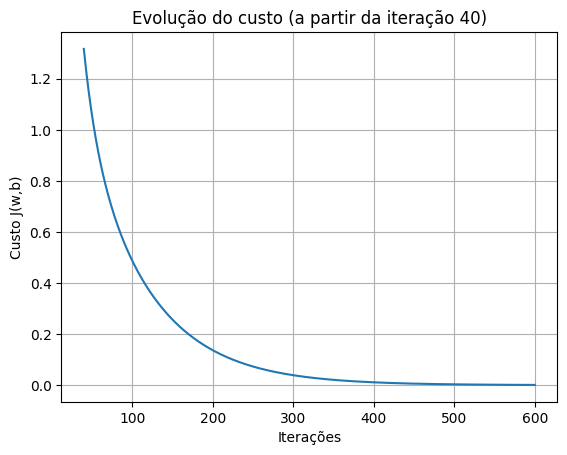

In [21]:
plt.plot(range(40, len(J_hist)), J_hist[40:])
plt.xlabel('Iterações')
plt.ylabel('Custo J(w,b)')
plt.title('Evolução do custo (a partir da iteração 40)')
plt.grid()
plt.show()

### Treinando o modelo com dados de treino

In [22]:
w0 = np.zeros(X_train.shape[1])
b0 = 0.0

alpha = 0.1
num_iters = 600

In [23]:
w_final, b_final, J_hist = gradient_descent(X_train, y_train, w0, b0, alpha, num_iters)


print('\nBias aprendido:', round(b_final, 3))
print('Pesos aprendidos:', np.round(w_final, 2))
print('\033[32mÚltimo custo:\033[0m', round(J_hist[-1], 7))

Iter  000: Cost 767463768.053836
Iter  100: Cost 74638958.219241
Iter  200: Cost 71506813.988286
Iter  300: Cost 70829519.420181
Iter  400: Cost 70668898.471649
Iter  500: Cost 70625988.416267
Iter  600: Cost 70613029.976478

Bias aprendido: 2.072
Pesos aprendidos: [ 0.86  0.12 -0.3   0.35 -0.   -0.04 -0.88 -0.85]
Último custo: 70613029.9764775


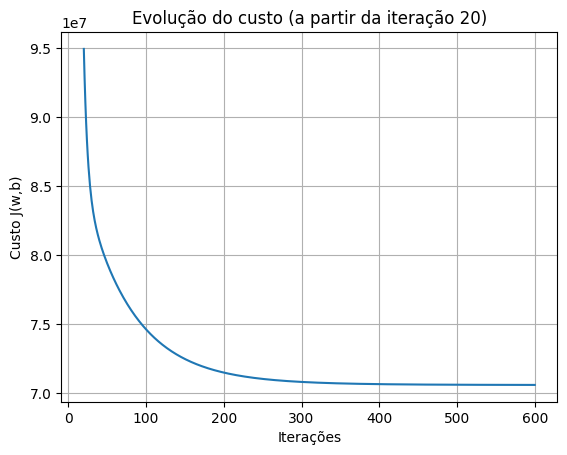

In [24]:
plt.plot(range(20, len(J_hist)), J_hist[20:])
plt.xlabel('Iterações')
plt.ylabel('Custo J(w,b)')
plt.title('Evolução do custo (a partir da iteração 20)')
plt.grid()
plt.show()

### Avaliando modelo

**Mean Squared Error (MSE)**  
Mede o erro médio quadrático entre valores reais $y_i$ e predições $\hat{y}_i$, quanto **menor** o MSE, melhor o ajuste..

$$ \mathrm{MSE} = \frac{1}{m}\sum_{i=1}^{m}\bigl(y_i - \hat{y}_i\bigr)^2 $$

**Coeficiente de determinação (R²)**  
Indica a fração da variância de $ y $ explicada pelo modelo.
$$ R^2 \;=\; 1 - \frac{\sum_{i=1}^{m}\bigl(y_i - \hat{y}_i\bigr)^2}{\sum_{i=1}^{m}\bigl(y_i - \bar{y}\bigr)^2} $$
onde: $$\bar{y} = \frac{1}{m}\sum_{i=1}^{m} y_i $$

Interpretação rápida:
- $R^2 \approx 1$: predições próximas dos valores reais (modelo explica bem a variância).  
- $R^2 \approx 0$: modelo não melhora em relação a sempre prever $\bar{y}$.  
- Pode ser **negativo** se o modelo for pior que a predição constante $\bar{y}$ (especialmente sem intercepto).

In [25]:
def avaliar_modelo(X, y, w, b):
    y_pred = X.dot(w) + b

    # Calcule o MSE e o R², de o valor de R² em porcentagem
    # (2 linhas de código)
    # SEU CÓDIGO COMEÇA AQUI
    mse = np.mean((y - y_pred)**2)
    r2 = 100 * (1 - (np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)))
    # SEU CÓDIGO TERMINA AQUI

    print(f'MSE: {mse:.2f} | R2: {r2:.2f}%')


In [26]:
avaliar_modelo(X_test, y_test, w_final, b_final)

MSE: 0.56 | R2: 57.55%


---

## 9. Conclusão

Em Machine Learning, escolhemos um modelo para aproximar a relação entre entradas e saídas. Na regressão linear, essa relação é: $ \hat{y} = w x + b $ 

Para medir quão bem o modelo explica os dados, definimos uma função de custo $J(w,b)$, que agrega os erros entre predições e valores reais em um único número. Por fim, usamos Gradient Descent para minimizar $J$: calculamos os gradientes de $J$ em relação a $w$ e $b$ e atualizamos os parâmetros iterativamente até chegar a valores que gerem erros menores e melhor ajuste.

Em conjunto, modelo (regressão linear), medida de erro (função de custo) e método de otimização (gradient descent) — é o esqueleto de grande parte do aprendizado de máquina. Em problemas mais complexos (como redes neurais), a ideia permanece: definir uma função de predição, quantificar o erro com um custo apropriado e otimizar os pesos via gradiente para aprender padrões a partir dos dados.

Como próximo passo, redes neurais generalizam o que acabamos de fazer: em vez de uma única combinação linear wx+b, temos vários neurônios que calculam combinações lineares seguidas de funções de ativação (por exemplo, ReLU na camada oculta e sigmóide na saída para classificação). Os parâmetros deixam de ser escalares e passam a ser matrizes e vetores (W, b) por camada; ainda assim, avaliamos o ajuste com uma função de custo (p.ex., entropia cruzada para classificação) e otimizamos com Gradient Descent, agora aplicado com retropropagação (backpropagation) para computar eficientemente os gradientes de todos os pesos. Em outras palavras: trocamos a reta por um conjunto de camadas que aprendem representações mais ricas, mas mantemos a mesma lógica de medir erro e minimizá-lo iterativamente.

In [ ]:
# ------------------- dados (como no seu exemplo) -------------------
x_pts = np.array([10, 30, 50, 70, 90, 110, 130, 150, 170, 190, 210, 230, 250, 270, 290, 310, 330, 350, 370, 390, 410, 430, 450, 470, 490, 510, 530, 550, 570, 590, 610, 630, 650, 670, 690, 710, 730, 750, 770, 790, 810, 830, 850, 870, 890, 910, 930, 950, 970, 990, 1010, 1030, 1050, 1070, 1090, 1110, 1130, 1150, 1170, 1190, 1210, 1230, 1250, 1270, 1290, 1310, 1330, 1350, 1370, 1390, 1410, 1430, 1450, 1470, 1490, 1510, 1530, 1550, 1570, 1590])
y_pts = np.array([0,  26,  42,  58,  74,  90, 106, 122, 138, 154, 170, 186, 202, 218, 234, 250, 266, 282, 298, 314, 330, 346, 362, 378, 394, 410, 426, 442, 458, 474, 490, 506, 522, 538, 554, 570, 586, 602, 618, 634, 650, 666, 682, 698, 714, 730, 746, 762, 778, 794, 810, 826, 842, 858, 874, 890, 906, 922, 938, 954, 970, 986, 1002, 1018, 1034, 1050, 1066, 1082, 1098, 1114, 1130, 1146, 1162, 1178, 1194, 1210, 1226, 1242, 1258, 1274])

rng = np.random.default_rng(42)
x_pts = x_pts + rng.integers(0, 131, size=x_pts.shape)  # ruído
y_pts = y_pts + rng.integers(0, 131, size=y_pts.shape)  # ruído

m = len(x_pts)

# custo MSE com fator 1/(2m) (forma clássica para GD)
def cost(w, b):
    y_hat = w * x_pts + b
    return (1/(2*m)) * np.sum((y_pts - y_hat)**2)

# eixo w para a curva J(w | b_atual)
w_axis = np.linspace(-2.0, 2.0, 400)

# limites do gráfico dos dados
x_max = max(1600, x_pts.max() * 1.02)
y_max = max(1500, y_pts.max() * 1.05)

# ---- b fixo (sem slider) ----
b_const = 20.0

def show(w=0.1):
    b = b_const

    # --------- figura com 2 painéis ---------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5), gridspec_kw={'wspace': 0.28})

    # --------- painel esquerdo: reta em cima dos dados ---------
    x_line = np.linspace(0, x_max, 600)
    y_line = w * x_line + b

    ax1.plot(x_line, y_line, label=f"y = {w:.2f}x + {b:.2f}")
    ax1.plot(x_pts, y_pts, linestyle="none", marker="x", markersize=6, label="dados (amostra)")

    ax1.axhline(0, color="k", lw=0.5); ax1.axvline(0, color="k", lw=0.5)
    ax1.set_xlim(0, x_max); ax1.set_ylim(0, y_max)
    ax1.set_title("Reta de regressão sobre os dados (b fixo)")
    ax1.set_xlabel("Tamanho (m²)")
    ax1.set_ylabel("Preço (R$)")
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc="upper left")

    # --------- painel direito: J(w | b_const) ---------
    J_axis = np.array([cost(wi, b) for wi in w_axis])
    J_curr = cost(w, b)

    ax2.plot(w_axis, J_axis, label=rf"$J(w\,|\,b={b:.1f})$")
    ax2.scatter([w], [J_curr], c="red", s=80, zorder=3, label=f"ponto (w, J) = ({w:.2f}, {J_curr:.1f})")
    ax2.axvline(w, color="red", linestyle=":", lw=1)

    ax2.set_xlabel("w")
    ax2.set_ylabel("Custo J(w)")
    ax2.set_title(f"Curva de custo em função de w (b = {b:.1f})")
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc="upper left")

    plt.show()

# Apenas slider de w
interact(show, w=FloatSlider(value=0.1, min=-2.0, max=2.0, step=0.05, description="w"))

interactive(children=(FloatSlider(value=0.1, description='w', max=2.0, min=-2.0, step=0.05), Output()), _dom_c…

<function __main__.show(w=0.1)>

---

## 10. Breve Introdução a DeepLearning e Redes Neurais

Na próxima aula vamos dar um passo além do que fizemos com regressão e classificação. Em vez de usar uma única reta para prever, vamos combinar vários “pequenos modelos” em sequência. Pense assim: cada “pezinho” do sistema faz uma conta simples do tipo $ w\cdot x + b $ e, em seguida, aplica uma transformação simples que decide “quanto dessa informação segue adiante”. Ao ligar vários desses blocos, o conjunto consegue desenhar fronteiras de decisão mais flexíveis, que não precisam ser apenas retas.

<p align="center">
  <img src="imgs/Picture5.png" alt="Legenda curta" width="420"><br>
  <em>Arquitetura de rede neural com múltiplas camadas ocultas.</em>
</p>